In [39]:
# Bibliotecas
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [40]:
# Carregar os dados
df = pd.read_csv('../../Data/PROCESSED/leads_processados_para_pbi.csv')

# Converter a variável target
df['target'] = df['status_conversao'].map({'Convertido': 1, 'Não Convertido': 0})

# Criar a variável binária 'converteu'
df['converteu'] = df['dias_ate_1o_trade'].notna().astype(int)

In [41]:
# Confirma que a coluna alvo está binária
df['converteu'] = df['converteu'].astype(int)

# 🎯 Embedding supervisionado: taxa de conversão por país
taxa_conversao_pais = df.groupby("pais")['converteu'].mean()

# Merge no dataframe original
df['pais_embedding'] = df['pais'].map(taxa_conversao_pais)

# Substitui valores ausentes (caso algum país não esteja mapeado)
df['pais_embedding'] = df['pais_embedding'].fillna(df['pais_embedding'].mean())

# Remove a coluna original
df = df.drop(columns=['pais'])

In [42]:
df.head(5)

,lead_id,data_cadastro,origem,perfil,dias_ate_1o_trade,valor_deposito,status_conversao,foi_convertido,ano,mes,semana,semana_str,target,ano_mes_cadastro,converteu,pais_embedding
0,49,2025-01-05,WhatsApp,Moderado,10.0,1394.3,Convertido,True,2025,1,1,1,1,2025-01,1,0.102424
1,309,2025-01-07,TikTok,Agressivo,NaN,0.0,Não Convertido,False,2025,1,1,1,0,2025-01,0,0.101969
2,356,2025-01-04,Google Ads,Moderado,NaN,0.0,Não Convertido,False,2025,1,1,1,0,2025-01,0,0.107882
3,557,2025-01-07,Instagram,Moderado,NaN,0.0,Não Convertido,False,2025,1,1,1,0,2025-01,0,0.099282
4,664,2025-01-05,Orgânico,Moderado,NaN,0.0,Não Convertido,False,2025,1,1,1,0,2025-01,0,0.103394


In [43]:
df_model = df.drop(columns=[
     'foi_convertido', 'status_conversao', 'ano_mes_cadastro', 'data_cadastro'
])

In [44]:
# One-hot encoding para variáveis categóricas
df_model = pd.get_dummies(df_model, columns=['origem', 'perfil'], drop_first=True)


In [45]:
# Calcula a média apenas dos que fizeram trade
media_convertidos = df_model.loc[df_model['converteu'] == 1, 'dias_ate_1o_trade'].mean()

# Preenche os NaNs com essa média
df_model['dias_ate_1o_trade'] = df_model['dias_ate_1o_trade'].fillna(media_convertidos)


In [46]:


scaler = StandardScaler()
df_model[['valor_deposito', 'pais_embedding']] = scaler.fit_transform(df_model[['valor_deposito', 'pais_embedding']])


In [47]:
X = df_model.drop(columns='converteu')
y = df_model['converteu']

In [48]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [49]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [50]:


lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train_resampled, y_train_resampled)
y_pred_lr = lr.predict(X_test)
print("🔍 Regressão Logística")
print(classification_report(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, y_pred_lr))


🔍 Regressão Logística
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     62823
           1       1.00      0.99      0.99      7177

    accuracy                           1.00     70000
   macro avg       1.00      0.99      1.00     70000
weighted avg       1.00      1.00      1.00     70000

AUC: 0.9940783056987599


c:\Users\leojo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [51]:


rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf.predict(X_test)
print("🌲 Random Forest")
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_pred_rf))


🌲 Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     62823
           1       1.00      1.00      1.00      7177

    accuracy                           1.00     70000
   macro avg       1.00      1.00      1.00     70000
weighted avg       1.00      1.00      1.00     70000

AUC: 1.0


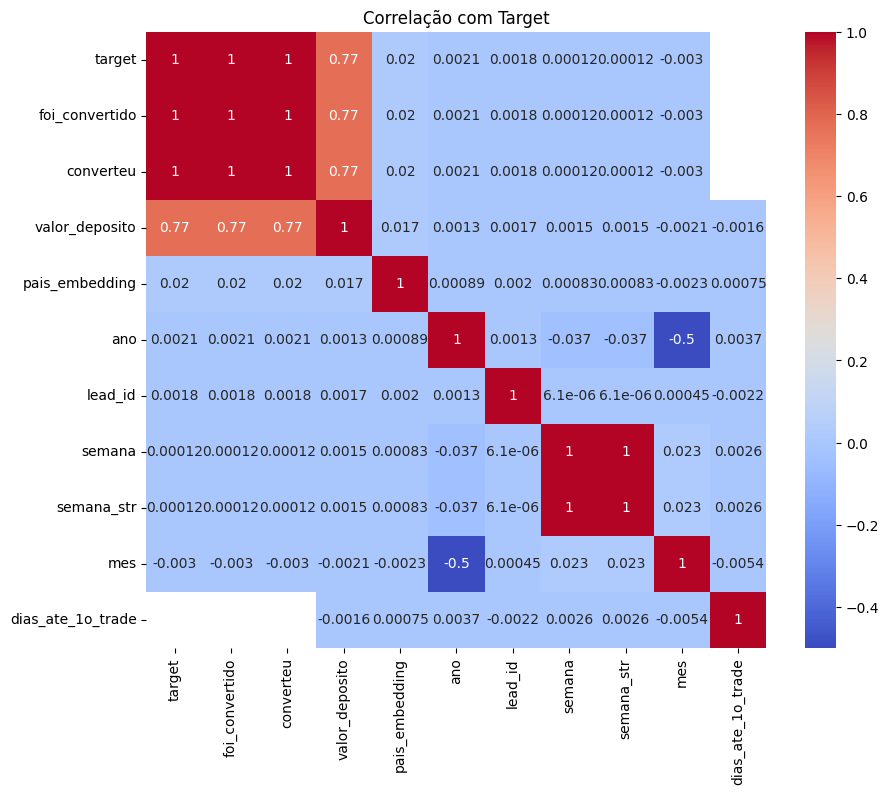

In [52]:

# Heatmap da correlação
corr_target = df.corr(numeric_only=True)['target'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_target.index].corr(), annot=True, cmap='coolwarm')
plt.title("Correlação com Target")
plt.show()



In [53]:
colunas_remover = [
    'lead_id', 
    'data_cadastro', 
    'ano_mes_cadastro',
    'valor_deposito',          # pós-conversão
    'dias_ate_1o_trade',       # só existe para convertidos
    'converteu',               # criado com base na conversão
    'status_conversao',        # duplicata semântica do target
    'target'                   # target não vai no X
]

X = df.drop(columns=colunas_remover)
y = df['target']


In [54]:
# Codificação de variáveis categóricas
X_encoded = pd.get_dummies(X, drop_first=True)

# Treino/teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, stratify=y, random_state=42)

# Padronização
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [55]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)


In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
model.fit(X_train_res, y_train_res)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     78529
           1       1.00      1.00      1.00      8971

    accuracy                           1.00     87500
   macro avg       1.00      1.00      1.00     87500
weighted avg       1.00      1.00      1.00     87500

AUC: 1.0


In [57]:
df_model

,lead_id,dias_ate_1o_trade,valor_deposito,ano,mes,semana,semana_str,target,converteu,pais_embedding,origem_Facebook,origem_Google Ads,origem_Indicação,origem_Instagram,origem_Orgânico,origem_TikTok,origem_WhatsApp,origem_YouTube Ads,perfil_Conservador,perfil_Moderado
0,49,10.000000,2.236632,2025,1,1,1,1,1,-0.016760,False,False,False,False,False,False,True,False,False,True
1,309,14.969987,-0.260462,2025,1,1,1,0,0,-0.091604,False,False,False,False,False,True,False,False,False,False
2,356,14.969987,-0.260462,2025,1,1,1,0,0,0.880589,False,True,False,False,False,False,False,False,False,True
3,557,14.969987,-0.260462,2025,1,1,1,0,0,-0.533211,False,False,False,True,False,False,False,False,False,True
4,664,14.969987,-0.260462,2025,1,1,1,0,0,0.142719,False,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349995,349302,14.969987,-0.260462,2023,12,5,5,0,0,-0.747800,False,False,False,True,False,False,False,False,False,True
349996,349623,14.969987,-0.260462,2023,12,5,5,0,0,-0.088687,False,False,False,False,False,False,False,True,False,True
349997,349695,14.969987,-0.260462,2023,12,5,5,0,0,-0.585108,False,True,False,False,False,False,False,False,False,True
349998,349890,14.969987,-0.260462,2023,12,5,5,0,0,-1.265555,True,False,False,False,False,False,False,False,False,False


In [58]:
# 🔹 Variáveis a serem removidas para evitar overfitting
cols_to_drop = ['lead_id', 'valor_deposito', 'dias_ate_1o_trade', 'target', 'converteu']

# 🔹 Definir X e y
X = df_model.drop(columns=cols_to_drop)
y = df_model['target']

# 🔹 Separar em treino/teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# 🔹 Padronização
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 Avaliar modelos novamente (por exemplo, regressão logística)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]

print("🔍 Regressão Logística após correção")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))


🔍 Regressão Logística após correção
              precision    recall  f1-score   support

           0       0.92      0.62      0.74     78529
           1       0.14      0.53      0.22      8971

    accuracy                           0.61     87500
   macro avg       0.53      0.58      0.48     87500
weighted avg       0.84      0.61      0.69     87500

AUC: 0.608106605493315


In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Balancear os dados
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 2. Treinar o modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_resampled, y_train_resampled)

# 3. Previsões
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

# 4. Resultados
print("🌲 Random Forest (com SMOTE)")
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_proba_rf))

🌲 Random Forest (com SMOTE)
              precision    recall  f1-score   support

           0       0.90      0.86      0.88     78529
           1       0.12      0.16      0.13      8971

    accuracy                           0.79     87500
   macro avg       0.51      0.51      0.51     87500
weighted avg       0.82      0.79      0.80     87500

AUC: 0.5257643733365858


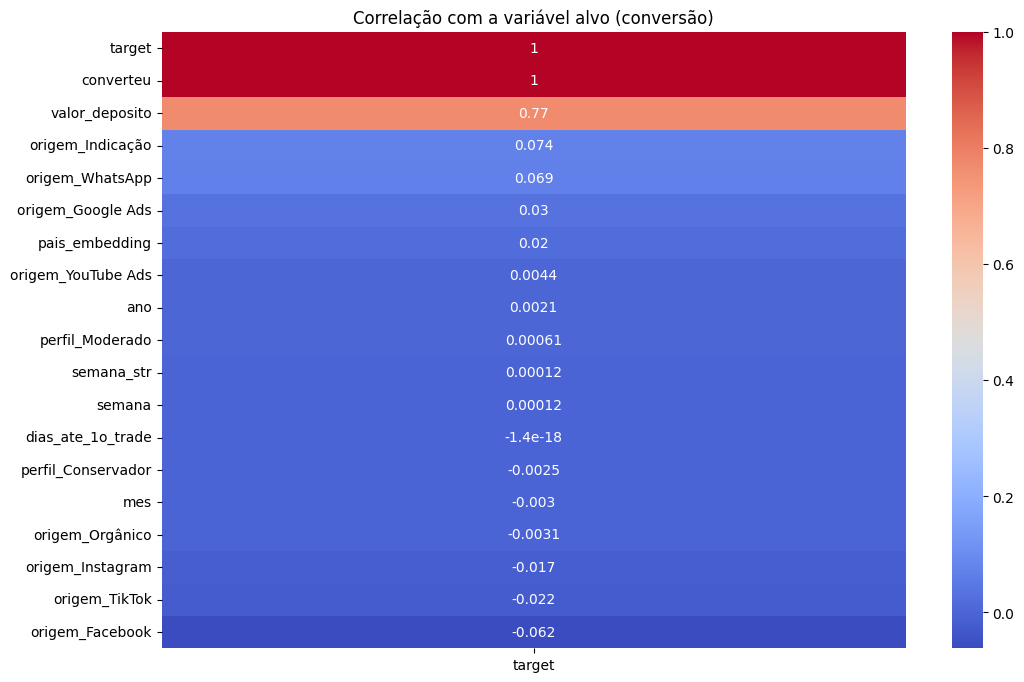

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_model.drop(columns=['lead_id']).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr[['target']].sort_values(by='target', ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlação com a variável alvo (conversão)")
plt.show()


In [61]:
# Reimporta o CSV original com todas as colunas
df_original = pd.read_csv('../../Data/PROCESSED/leads_processados_para_pbi.csv', parse_dates=['data_cadastro'])

# Garante que a coluna existe e é datetime
df_original['data_cadastro'] = pd.to_datetime(df_original['data_cadastro'], errors='coerce')

# 🔁 1. Tempo desde o cadastro
data_atual = pd.to_datetime(datetime.today().date())
df_original['dias_desde_cadastro'] = (data_atual - df_original['data_cadastro']).dt.days

# 🔁 2. Mês do cadastro (efeito sazonal)
df_original['mes_cadastro'] = df_original['data_cadastro'].dt.month

# 🔁 3. Dias sem conversão (só para não convertidos)
df_original['dias_sem_conversao'] = df_original.apply(
    lambda row: row['dias_ate_1o_trade'] if pd.notnull(row['dias_ate_1o_trade']) 
    else row['dias_desde_cadastro'], axis=1
)

# 🔁 4. Clusterização dos países com base no embedding
from sklearn.cluster import KMeans

# Vamos simular um embedding por frequência para exemplo
pais_freq = df_original['pais'].value_counts(normalize=True).to_dict()
df_original['pais_embedding'] = df_original['pais'].map(pais_freq)

# Aplica KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
df_original['cluster_pais'] = kmeans.fit_predict(df_original[['pais_embedding']])


In [63]:
# Faz merge com base no lead_id
df_model = df_model.merge(
    df_original[['lead_id', 'dias_desde_cadastro', 'mes_cadastro', 'dias_sem_conversao', 'cluster_pais']],
    on='lead_id',
    how='left'
)


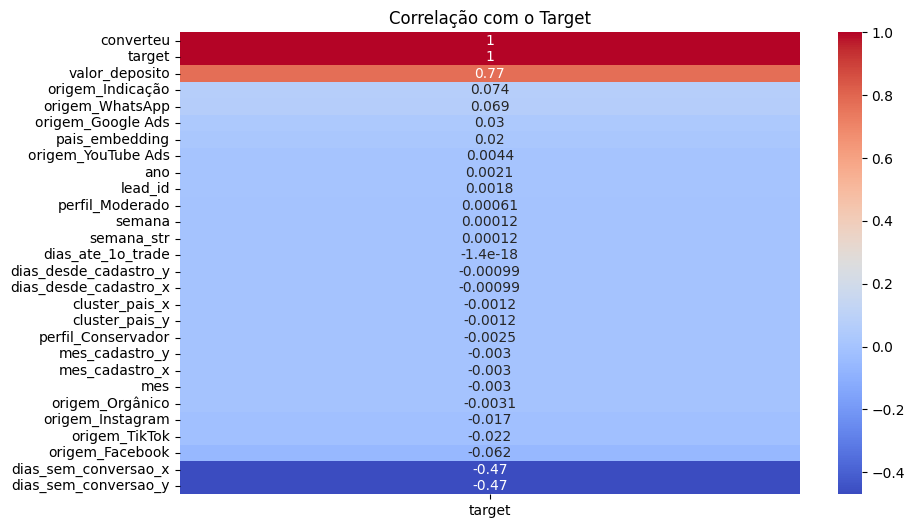

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlação com a variável alvo (target ou converteu)
corr = df_model.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr[['target']].sort_values(by='target', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlação com o Target')
plt.show()


In [65]:
# 🎯 Etapa 1: Seleção de features e target
colunas_modelo = [
    'valor_deposito',
    'dias_sem_conversao',
    'pais_embedding',
    'mes_cadastro',
    'dias_desde_cadastro',
    'cluster_pais',
    'origem_Facebook', 'origem_Google Ads', 'origem_Indicação',
    'origem_Instagram', 'origem_Orgânico', 'origem_TikTok',
    'origem_WhatsApp', 'origem_YouTube Ads',
    'perfil_Conservador', 'perfil_Desconhecido', 'perfil_Moderado'
]

# X e y
X = df_model[colunas_modelo].copy()
y = df_model['target'].astype(int)  # Garantir que é numérico

# Verificar rapidamente
print("Shape de X:", X.shape)
print("Distribuição de y:\n", y.value_counts(normalize=True))


KeyError: "['dias_sem_conversao', 'mes_cadastro', 'dias_desde_cadastro', 'cluster_pais', 'perfil_Desconhecido'] not in index"

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1️⃣ Split com stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2️⃣ SMOTE (apenas no treino)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 3️⃣ Padronização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# 🔎 Verificações rápidas
print("Treino balanceado:", y_train_smote.value_counts(normalize=True))
print("Shape após SMOTE:", X_train_scaled.shape)


Treino balanceado: target
0    0.5
1    0.5
Name: proportion, dtype: float64
Shape após SMOTE: (502586, 15)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1️⃣ Regressão Logística
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_smote)
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("🔍 Regressão Logística")
print(classification_report(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, y_proba_lr))

# 2️⃣ Random Forest
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train_scaled, y_train_smote)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("\n🌲 Random Forest")
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_proba_rf))


🔍 Regressão Logística
              precision    recall  f1-score   support

           0       0.92      0.62      0.74     62823
           1       0.14      0.53      0.22      7177

    accuracy                           0.61     70000
   macro avg       0.53      0.57      0.48     70000
weighted avg       0.84      0.61      0.68     70000

AUC: 0.6020051744466997


In [31]:
df_model = df_model.drop(columns=[
    'valor_deposito', 
    'converteu', 
    'dias_ate_1o_trade'  # ou normalize ela se quiser manter como proxy temporal
])


In [33]:
features_to_remove = ['valor_deposito', 'converteu', 'dias_ate_1o_trade']
features_to_remove = [col for col in features_to_remove if col in df_model.columns]

X_filtered = df_model.drop(columns=features_to_remove + ['target'])
y = df_model['target']



In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y, stratify=y, random_state=42
)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [36]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Regressão Logística
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_resampled, y_train_resampled)
y_pred_lr = lr.predict(X_test_scaled)
print("🔍 Regressão Logística")
print(classification_report(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf.predict(X_test_scaled)
print("\n🌲 Random Forest")
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:, 1]))


🔍 Regressão Logística
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     63495
           1       0.74      0.97      0.84      3367

    accuracy                           0.98     66862
   macro avg       0.87      0.98      0.92     66862
weighted avg       0.99      0.98      0.98     66862

AUC: 0.9978092889503237

🌲 Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     63495
           1       1.00      0.99      0.99      3367

    accuracy                           1.00     66862
   macro avg       1.00      0.99      1.00     66862
weighted avg       1.00      1.00      1.00     66862

AUC: 0.9999484698988597


In [38]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cross_val_score(rf, X_train_resampled, y_train_resampled, cv=StratifiedKFold(5), scoring='roc_auc').mean()


np.float64(0.9999955675331377)